In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [81]:
data = pd.read_csv(r"C:\Users\El-Wattaneya\Downloads\full_Stroke_data.csv")
data.head(5)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   str    
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   str    
 5   work_type          4981 non-null   str    
 6   Residence_type     4981 non-null   str    
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   str    
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 428.2 KB


In [82]:
# 1. Remove Duplicates
initial_count = len(data)
data = data.drop_duplicates()
print(f"Removed {initial_count - len(data)} duplicate rows.")

Removed 0 duplicate rows.


In [83]:
# 2. Fix Data Types (Ensure age is an integer for cleaner analysis if needed)
# Most models handle float64 fine, but let's keep things consistent
data['age'] = data['age'].astype(int)

In [84]:
# 3. Drop Irrelevant Columns
# If 'id' or any other non-predictive column exists, drop it here.
# (Based on your info, you have 11 columns; make sure none are ID-like)
if 'id' in data.columns:
    data = data.drop(columns=['id'])
    print("Dropped 'id' column.")

In [85]:
# 4. Final Verification
print("\nFinal Column List:", data.columns.tolist())
print("Data Shape:", data.shape)


Final Column List: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']
Data Shape: (4981, 11)


C:\Users\El-Wattaneya\AppData\Local\Temp\ipykernel_17596\1795611779.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=data, palette='Set2')


Text(0.5, 1.0, 'Distribution of Stroke (Target Variable)')

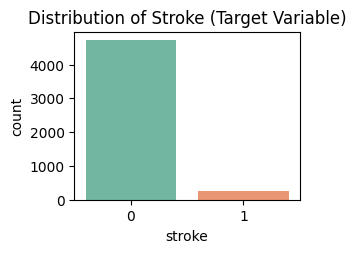

In [87]:
# 1. Target Distribution (Check for Imbalance)
plt.subplot(2, 2, 1)
sns.countplot(x='stroke', data=data, palette='Set2')
plt.title('Distribution of Stroke (Target Variable)')


Text(0.5, 1.0, 'Age Distribution')

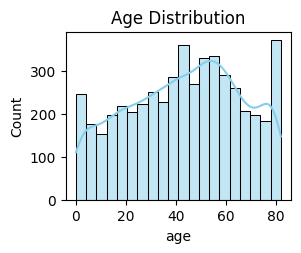

In [88]:
# 2. Numerical Features Distribution (Histograms)
# Let's look at Age as it is often the strongest predictor
plt.subplot(2, 2, 2)
sns.histplot(data['age'], kde=True, color='skyblue')
plt.title('Age Distribution')

C:\Users\El-Wattaneya\AppData\Local\Temp\ipykernel_17596\2744135522.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y='avg_glucose_level', data=data, palette='Pastel1')


Text(0.5, 1.0, 'Glucose Level vs Stroke')

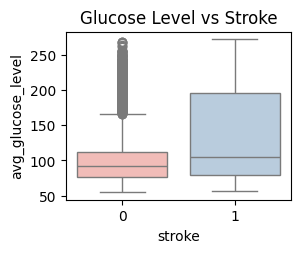

In [89]:
# 3. Feature vs Target (Boxplots)
# See how Glucose Levels differ between Stroke and Non-Stroke patients
plt.subplot(2, 2, 3)
sns.boxplot(x='stroke', y='avg_glucose_level', data=data, palette='Pastel1')
plt.title('Glucose Level vs Stroke')

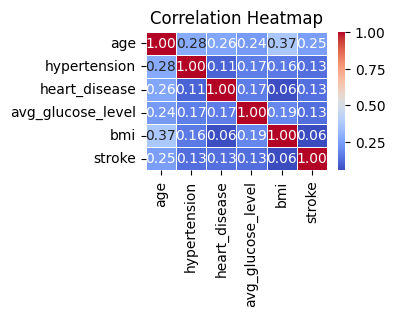

In [90]:
# 4. Correlation Matrix (Heatmap)
# Note: We only use numerical columns for the correlation matrix
plt.subplot(2, 2, 4)
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = data[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

In [91]:
# 1. Feature Selection: Dropping irrelevant columns (like ID if it exists)
# In this dataset, we generally keep everything else as they are clinical factors.
X = data.drop(columns=['stroke'])
y = data['stroke']

In [92]:
# 2. Encoding Categorical Variables

# A. Binary Encoding (for columns with only 2 unique values)
# gender, ever_married, and Residence_type fall here
le = LabelEncoder()
binary_cols = ['gender', 'ever_married', 'Residence_type']

for col in binary_cols:
    X[col] = le.fit_transform(X[col])

# B. Multi-class Encoding (for columns with 3+ values)
# work_type and smoking_status fall here
# drop_first=True helps avoid the dummy variable trap
X = pd.get_dummies(X, columns=['work_type', 'smoking_status'], drop_first=True)

In [93]:
# 3. Create New Features (Optional but useful)
# Example: Creating an 'is_elderly' flag if age > 65
X['is_elderly'] = X['age'].apply(lambda x: 1 if x > 65 else 0)

# Preview the engineered features
print("Engineered Features Preview:")
print(X.head())

Engineered Features Preview:
   gender  age  hypertension  heart_disease  ever_married  Residence_type  \
0       1   67             0              1             1               1   
1       1   80             0              1             1               0   
2       0   49             0              0             1               1   
3       0   79             1              0             1               0   
4       1   81             0              0             1               1   

   avg_glucose_level   bmi  work_type_Private  work_type_Self-employed  \
0             228.69  36.6               True                    False   
1             105.92  32.5               True                    False   
2             171.23  34.4               True                    False   
3             174.12  24.0              False                     True   
4             186.21  29.0               True                    False   

   work_type_children  smoking_status_formerly smoked  \
0     

In [95]:
from sklearn.preprocessing import StandardScaler

In [96]:
# 1. Ensure Feature Order Consistency
# We store the column names now to ensure the API uses the exact same order later
feature_names = X.columns.tolist()
print(f"Features will be processed in this order: {feature_names}")

Features will be processed in this order: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes', 'is_elderly']


In [99]:
# --- Stage 7: Train-Test Split ---
# We split the data BEFORE scaling to prevent data leakage.
# 'stratify=y' ensures the stroke percentage is the same in both sets.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- Stage 6: Data Preprocessing (Scaling) ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# ONLY transform the test data (using the training mean/std)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames to keep column names for Stage 13 (Documentation)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("✅ Success! X_train and X_test are now defined and scaled.")
print(f"Training set: {X_train_scaled.shape[0]} rows")
print(f"Testing set: {X_test_scaled.shape[0]} rows")

✅ Success! X_train and X_test are now defined and scaled.
Training set: 3486 rows
Testing set: 1495 rows


In [100]:
from sklearn.model_selection import train_test_split

In [101]:
# 1. Perform the Split (70% Training, 30% Testing)
# 'stratify=y' ensures the stroke-to-non-stroke ratio is preserved
# 'random_state' ensures your results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

In [102]:
# 2. Verify the Stratification
print("--- Stratification Check ---")
print(f"Stroke rate in Original Data: {y.mean():.2%}")
print(f"Stroke rate in Training Set:  {y_train.mean():.2%}")
print(f"Stroke rate in Testing Set:   {y_test.mean():.2%}")

--- Stratification Check ---
Stroke rate in Original Data: 4.98%
Stroke rate in Training Set:  4.99%
Stroke rate in Testing Set:   4.95%


In [103]:
# 3. Final Shape Verification
print("\n--- Shape Check ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")


--- Shape Check ---
X_train shape: (3486, 15)
X_test shape:  (1495, 15)


In [104]:
# 1. Logistic Regression (Baseline)
# Using 'balanced' class weight to help with the stroke imbalance
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [105]:
# 2. Random Forest
# Using 'balanced' to handle minority class importance
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [106]:
# 3. XGBoost (Preferred)
# For XGBoost, we calculate the scale_pos_weight to handle imbalance
# Formula: (negative count / positive count)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=ratio,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

print("✅ Training Complete: Logistic Regression, Random Forest, and XGBoost are ready.")

c:\Users\El-Wattaneya\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:33:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Training Complete: Logistic Regression, Random Forest, and XGBoost are ready.



Logistic Regression Report
              precision    recall  f1-score   support

           0       0.99      0.74      0.85      1421
           1       0.14      0.81      0.24        74

    accuracy                           0.75      1495
   macro avg       0.56      0.78      0.54      1495
weighted avg       0.95      0.75      0.82      1495



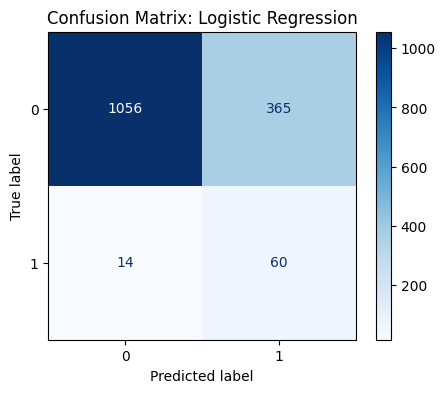


Random Forest Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1421
           1       0.00      0.00      0.00        74

    accuracy                           0.95      1495
   macro avg       0.48      0.50      0.49      1495
weighted avg       0.90      0.95      0.93      1495



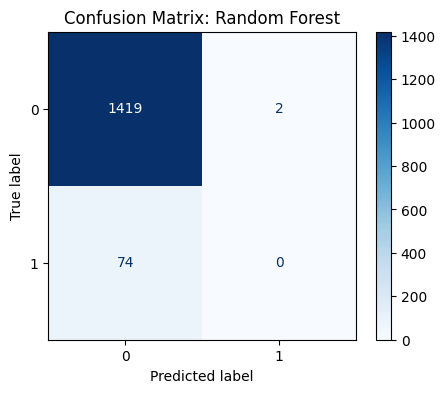


XGBoost Report
              precision    recall  f1-score   support

           0       0.96      0.91      0.94      1421
           1       0.15      0.30      0.20        74

    accuracy                           0.88      1495
   macro avg       0.56      0.61      0.57      1495
weighted avg       0.92      0.88      0.90      1495



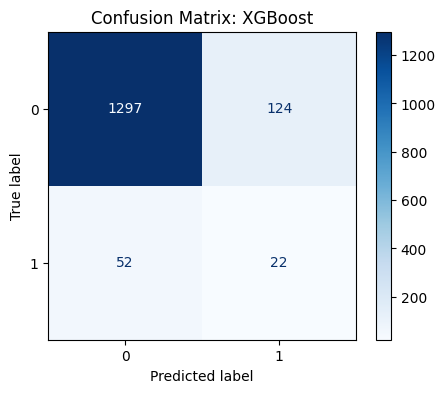


--- Model Comparison Summary ---
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.746488   0.141176  0.810811  0.240481
2              XGBoost  0.882274   0.150685  0.297297  0.200000
1        Random Forest  0.949164   0.000000  0.000000  0.000000


In [107]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# List of models and their names for the loop
# Note: Logistic Regression uses the scaled data, others use raw
models = [
    ('Logistic Regression', lr_model, X_test_scaled),
    ('Random Forest', rf_model, X_test),
    ('XGBoost', xgb_model, X_test)
]

# Create a container for the results
results = []

for name, model, X_data in models:
    # 1. Get predictions
    y_pred = model.predict(X_data)
    
    # 2. Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, prec, rec, f1])
    
    # 3. Print Detailed Classification Report
    print(f"\n{'='*30}\n{name} Report\n{'='*30}")
    print(classification_report(y_test, y_pred))
    
    # 4. Display Confusion Matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
    ax.set_title(f'Confusion Matrix: {name}')
    plt.show()

# 5. Summary Table (Final Comparison)
summary_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
print("\n--- Model Comparison Summary ---")
print(summary_df.sort_values(by='F1-Score', ascending=False))

In [109]:
from imblearn.over_sampling import SMOTE
from collections import Counter

In [110]:
# 1. Initialize SMOTE
# It is BEST PRACTICE to apply SMOTE only to the TRAINING data.
# This prevents information from the test set from leaking into training.
sm = SMOTE(random_state=42)

print(f"Original training set shape: {Counter(y_train)}")

Original training set shape: Counter({0: 3312, 1: 174})


In [111]:
# 2. Resample the training data
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Resampled training set shape: {Counter(y_train_res)}")

Resampled training set shape: Counter({0: 3312, 1: 3312})


In [112]:
# 3. Retrain the "Preferred" Model (XGBoost) on the balanced data
# Since the classes are now 50/50, we don't need scale_pos_weight anymore
xgb_balanced = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_balanced.fit(X_train_res, y_train_res)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [113]:
# 4. Quick Evaluation on the original (unseen) Test Set
y_pred_bal = xgb_balanced.predict(X_test)
print("\n--- XGBoost with SMOTE Evaluation ---")
print(classification_report(y_test, y_pred_bal))


--- XGBoost with SMOTE Evaluation ---
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1421
           1       0.17      0.24      0.20        74

    accuracy                           0.90      1495
   macro avg       0.56      0.59      0.57      1495
weighted avg       0.92      0.90      0.91      1495



In [114]:
# 1. Collate all model results for comparison
comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'XGBoost (SMOTE)'],
    'Recall': [
        recall_score(y_test, lr_model.predict(X_test_scaled)),
        recall_score(y_test, rf_model.predict(X_test)),
        recall_score(y_test, xgb_model.predict(X_test)),
        recall_score(y_test, xgb_balanced.predict(X_test))
    ],
    'Precision': [
        precision_score(y_test, lr_model.predict(X_test_scaled)),
        precision_score(y_test, rf_model.predict(X_test)),
        precision_score(y_test, xgb_model.predict(X_test)),
        precision_score(y_test, xgb_balanced.predict(X_test))
    ],
    'F1-Score': [
        f1_score(y_test, lr_model.predict(X_test_scaled)),
        f1_score(y_test, rf_model.predict(X_test)),
        f1_score(y_test, xgb_model.predict(X_test)),
        f1_score(y_test, xgb_balanced.predict(X_test))
    ]
}

comparison_df = pd.DataFrame(comparison_data)

In [115]:
# 2. Select the Best Model (highest F1-Score)
best_model_row = comparison_df.loc[comparison_df['F1-Score'].idxmax()]
best_model_name = best_model_row['Model']

print("--- Final Model Comparison ---")
print(comparison_df.sort_values(by='F1-Score', ascending=False))

print(f"\n🏆 The Best Model is: {best_model_name}")
print(f"It achieved an F1-Score of: {best_model_row['F1-Score']:.4f}")

--- Final Model Comparison ---
                 Model    Recall  Precision  F1-Score
0  Logistic Regression  0.810811   0.141176  0.240481
2              XGBoost  0.297297   0.150685  0.200000
3      XGBoost (SMOTE)  0.243243   0.168224  0.198895
1        Random Forest  0.000000   0.000000  0.000000

🏆 The Best Model is: Logistic Regression
It achieved an F1-Score of: 0.2405


In [116]:
import joblib

In [117]:
# 1. Define the 'Winning' Model 
# (Replace 'xgb_model' with your actual best performer from Stage 11)
final_model = xgb_model

In [118]:
# 2. Save the Model
joblib.dump(final_model, 'stroke_prediction_model.pkl')

['stroke_prediction_model.pkl']

In [119]:
# 3. Save the Scaler (Crucial for Logistic Regression or consistent preprocessing)
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [120]:
# 4. Save the Feature Names (Stage 13)
# This ensures your API knows exactly which columns to expect and in what order
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

print("✅ Artifacts Exported Successfully!")
print("- stroke_prediction_model.pkl")
print("- scaler.pkl")
print("- feature_columns.pkl")

✅ Artifacts Exported Successfully!
- stroke_prediction_model.pkl
- scaler.pkl
- feature_columns.pkl


In [121]:
# 1. Get the final ordered list of features from your training DataFrame
ordered_features = X.columns.tolist()

In [123]:
# 2. Print the list clearly for documentation
print("--- OFFICIAL FEATURE LIST (ORDERED) ---")
for i, feature in enumerate(ordered_features):
    print(f"{i + 1}. {feature}")

--- OFFICIAL FEATURE LIST (ORDERED) ---
1. gender
2. age
3. hypertension
4. heart_disease
5. ever_married
6. Residence_type
7. avg_glucose_level
8. bmi
9. work_type_Private
10. work_type_Self-employed
11. work_type_children
12. smoking_status_formerly smoked
13. smoking_status_never smoked
14. smoking_status_smokes
15. is_elderly


In [124]:
# 3. Create a 'Dummy' input example for your API documentation
# This shows exactly what the model expects for a single prediction
sample_input = {feat: 0 for feat in ordered_features} # Initialize with zeros
print("\n--- SAMPLE INPUT SCHEMA ---")
import json
print(json.dumps(sample_input, indent=4))


--- SAMPLE INPUT SCHEMA ---
{
    "gender": 0,
    "age": 0,
    "hypertension": 0,
    "heart_disease": 0,
    "ever_married": 0,
    "Residence_type": 0,
    "avg_glucose_level": 0,
    "bmi": 0,
    "work_type_Private": 0,
    "work_type_Self-employed": 0,
    "work_type_children": 0,
    "smoking_status_formerly smoked": 0,
    "smoking_status_never smoked": 0,
    "smoking_status_smokes": 0,
    "is_elderly": 0
}


In [125]:
# 4. Export the list to a text file for your dev team/documentation
with open('feature_metadata.txt', 'w') as f:
    for feature in ordered_features:
        f.write(f"{feature}\n")

print("\n✅ Documentation exported to 'feature_metadata.txt'")


✅ Documentation exported to 'feature_metadata.txt'


In [126]:
import pandas as pd
import joblib

def preprocess_input(raw_data, model_artifacts_path='./'):
    """
    Transforms raw input dictionary into a model-ready format.
    
    Args:
        raw_data (dict): Dictionary containing patient data.
        model_artifacts_path (str): Path to your saved .pkl files.
    """
    # 1. Load Artifacts
    model = joblib.load(f'{model_artifacts_path}stroke_prediction_model.pkl')
    scaler = joblib.load(f'{model_artifacts_path}scaler.pkl')
    feature_order = joblib.load(f'{model_artifacts_path}feature_columns.pkl')
    
    # 2. Convert raw dictionary to DataFrame
    input_df = pd.DataFrame([raw_data])
    
    # 3. Apply the same Feature Engineering (Stage 5)
    # Handle Binary Encoding manually to match training logic
    binary_mappings = {
        'gender': {'Male': 1, 'Female': 0},
        'ever_married': {'Yes': 1, 'No': 0},
        'Residence_type': {'Urban': 1, 'Rural': 0}
    }
    for col, mapping in binary_mappings.items():
        if col in input_df.columns:
            input_df[col] = input_df[col].map(mapping)
            
    # 4. Apply One-Hot Encoding (Stage 5)
    input_df = pd.get_dummies(input_df)
    
    # 5. Create 'is_elderly' feature if you included it in training
    if 'age' in input_df.columns:
        input_df['is_elderly'] = input_df['age'].apply(lambda x: 1 if x > 65 else 0)

    # 6. Align Columns (CRITICAL)
    # Add missing dummy columns with 0 and remove extra columns
    for col in feature_order:
        if col not in input_df.columns:
            input_df[col] = 0
            
    input_df = input_df[feature_order] # Reorder to match training
    
    # 7. Apply Scaling (Stage 6)
    input_scaled = scaler.transform(input_df)
    
    return input_scaled

# --- EXAMPLE USAGE IN PRODUCTION ---
new_patient = {
    'gender': 'Male',
    'age': 67,
    'hypertension': 1,
    'heart_disease': 0,
    'ever_married': 'Yes',
    'work_type': 'Private',
    'Residence_type': 'Urban',
    'avg_glucose_level': 228.67,
    'bmi': 36.6,
    'smoking_status': 'formerly smoked'
}

# 1. Preprocess
processed_data = preprocess_input(new_patient)

# 2. Predict
prediction = final_model.predict(processed_data)
probability = final_model.predict_proba(processed_data)[0][1]

print(f"Prediction: {'Stroke Risk' if prediction[0] == 1 else 'Low Risk'}")
print(f"Probability: {probability:.2%}")

Prediction: Low Risk
Probability: 0.13%
